# DATA PREPARATION

## Studi Kasus: Iris Flower Dataset

## Pendahuluan

Data preparation merupakan tahap penting dalam proses data mining dan machine learning. Tahap ini bertujuan untuk menyiapkan data agar siap digunakan dalam proses analisis dan pemodelan. Proses ini meliputi pembersihan data, transformasi data, serta pemilihan fitur yang relevan.

Pada studi kasus ini digunakan **Iris Flower Dataset**, yaitu dataset klasik yang sering digunakan dalam pembelajaran machine learning. Dataset ini berisi informasi mengenai ukuran bunga iris, seperti panjang dan lebar sepal serta petal, yang digunakan untuk mengklasifikasikan bunga ke dalam tiga spesies yaitu **Iris-setosa, Iris-versicolor, dan Iris-virginica**.

---

## 3.1 Konsep Data Preparation dalam CRISP-DM

CRISP-DM (Cross Industry Standard Process for Data Mining) merupakan metodologi yang umum digunakan dalam proses data mining. Salah satu tahap penting dalam CRISP-DM adalah **Data Preparation**.

Tahap ini mencakup beberapa aktivitas utama, yaitu:

* **Data Cleaning**: membersihkan data dari nilai yang hilang atau duplikasi
* **Data Transformation**: mengubah data ke format yang sesuai
* **Feature Selection**: memilih fitur yang relevan untuk model
* **Data Integration**: menggabungkan data dari berbagai sumber

Tujuan utama tahap ini adalah memastikan data memiliki kualitas yang baik sebelum digunakan untuk proses pemodelan.

---

## Persiapan Lingkungan Analisis

Sebelum melakukan analisis data, kita perlu menyiapkan lingkungan kerja dengan mengimpor library yang dibutuhkan.

## 3.2 Import Library

Beberapa library Python yang digunakan dalam analisis ini antara lain:

* **pandas** untuk manipulasi data
* **numpy** untuk operasi numerik
* **matplotlib** dan **seaborn** untuk visualisasi data
* **scikit-learn** untuk dataset dan preprocessing

Contoh kode:

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Membaca Dataset

Dataset perlu dimuat ke dalam lingkungan analisis sebelum dapat diproses.

## 3.3 Memuat Dataset Awal

Dataset Iris dapat dimuat menggunakan library **scikit-learn** atau dari file CSV.

Contoh menggunakan scikit-learn



In [1]:
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df.head()

NameError: name 'pd' is not defined

Dataset ini memiliki beberapa fitur utama:

* sepal length
* sepal width
* petal length
* petal width
* species (target)

---

## Pembersihan Data

Tahap pembersihan data bertujuan untuk memastikan data tidak memiliki masalah yang dapat mempengaruhi hasil analisis.


## 3.4 Pemeriksaan Duplikasi

Data duplikat dapat menyebabkan bias dalam model. Oleh karena itu perlu dilakukan pengecekan duplikasi.

df.duplicated().sum()

Jika terdapat data duplikat, data tersebut dapat dihapus dengan:

df = df.drop_duplicates()

In [16]:
df.duplicated().sum()
df = df.drop_duplicates()

## 3.5 Pemeriksaan Missing Value

Missing value merupakan nilai yang tidak tersedia dalam dataset.

In [17]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Jika terdapat missing value, beberapa metode penanganannya antara lain:

* menghapus baris yang memiliki missing value
* mengganti dengan nilai rata-rata
* menggunakan metode imputasi

Pada dataset Iris biasanya tidak terdapat missing value.

---

## Transformasi Data

Transformasi data dilakukan untuk mengubah data agar lebih sesuai digunakan oleh algoritma machine learning.

## 3.6 Encoding Label

Karena model machine learning membutuhkan data numerik, maka label kategori perlu diubah menjadi angka.

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

## Seleksi Fitur

Feature selection bertujuan untuk memilih fitur yang paling relevan untuk model.

## 3.7 Pemisahan Fitur dan Target

Dataset dipisahkan menjadi fitur (X) dan target (y).

In [19]:
X = df.drop('species', axis=1)
y = df['species']

## Standarisasi Fitur

Standarisasi dilakukan agar semua fitur memiliki skala yang sama sehingga model dapat bekerja lebih optimal.

## 3.8 Alasan Dilakukan Scaling

Beberapa algoritma machine learning sangat sensitif terhadap skala data, seperti:

* KNN
* SVM
* Logistic Regression
* Neural Network

Scaling membantu:

* mempercepat proses pelatihan model
* meningkatkan akurasi model
* menghindari dominasi fitur dengan nilai besar

---


## Visualisasi Sebelum dan Sesudah Scaling

Visualisasi membantu memahami distribusi data sebelum dan sesudah dilakukan transformasi.

## 3.9 Sebelum Scaling

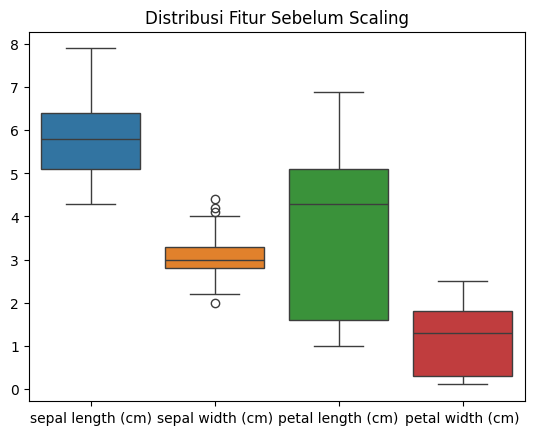

In [23]:
sns.boxplot(data=X)
plt.title("Distribusi Fitur Sebelum Scaling")
plt.show()

Visualisasi ini menunjukkan bahwa setiap fitur memiliki skala yang berbeda.

## 3.10 Sesudah Scaling




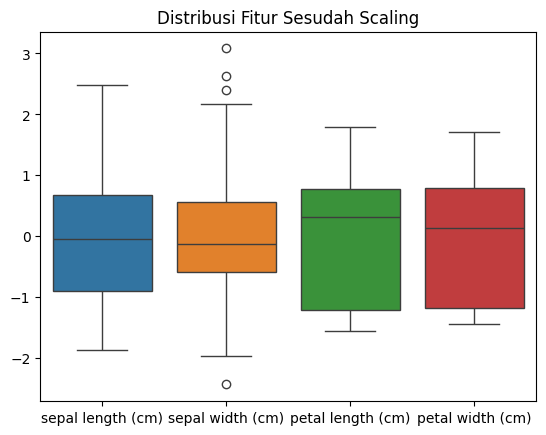

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

sns.boxplot(data=pd.DataFrame(X_scaled, columns=X.columns))
plt.title("Distribusi Fitur Sesudah Scaling")
plt.show()

Setelah dilakukan scaling, distribusi data menjadi lebih seragam sehingga dapat meningkatkan performa model machine learning.

---

Dengan melalui tahapan **data preparation**, dataset telah siap digunakan pada tahap berikutnya yaitu **modeling atau pembuatan model machine learning**.

## Menyimpan Dataset Hasil Preprocessing untuk Tahap Pemodelan

Setelah seluruh proses **data preparation** selesai dilakukan, langkah berikutnya adalah menyimpan dataset yang telah diproses. Dataset ini nantinya akan digunakan pada tahap **modeling** atau pembuatan model machine learning.

Pada tahap ini, fitur yang telah melalui proses **standarisasi (scaling)** digabungkan kembali dengan variabel target sehingga menghasilkan dataset akhir yang siap digunakan dalam proses analisis lebih lanjut.

Dataset yang telah diproses kemudian disimpan dalam format **CSV** agar mudah digunakan kembali pada tahap pemodelan maupun analisis lanjutan.

Berikut contoh kode untuk membuat dataset akhir dan menyimpannya ke dalam file CSV.

In [22]:
df_final = pd.DataFrame(X_scaled, columns=X.columns)
df_final["class_label"] = y

df_final.to_csv("iris_preprocessed_dataset.csv", index=False)

df_final.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class_label
0,-0.898033,1.012401,-1.333255,-1.308624,0.0
1,-1.139562,-0.137353,-1.333255,-1.308624,0.0
2,-1.381091,0.322549,-1.390014,-1.308624,0.0
3,-1.501855,0.092598,-1.276496,-1.308624,0.0
4,-1.018798,1.242352,-1.333255,-1.308624,0.0


Dengan demikian dataset telah siap digunakan untuk tahap berikutnya yaitu model development atau pembangunan model machine learning.